### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [6]:
print(f"Total number of data in data set: {data.shape[0]}")

print(f"Missing values per column:\n{data.isnull().sum()}")

print(f"Percentage of missing values in each column:\n{data.isnull().mean() * 100}")

data.sample(5)

Total number of data in data set: 12684
Missing values per column:
destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64
Percentage of missing values in each column:
destination              0.000000
passanger                0.000000
weather                  0.

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
933,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Female,31,Single,...,4~8,4~8,4~8,4~8,1,1,0,0,1,1
4560,Home,Alone,Sunny,80,10PM,Restaurant(<20),2h,Female,31,Married partner,...,1~3,4~8,1~3,less1,1,0,0,1,0,1
9812,No Urgent Place,Alone,Sunny,80,10AM,Coffee House,2h,Female,21,Single,...,1~3,4~8,1~3,less1,1,1,0,0,1,0
10548,No Urgent Place,Friend(s),Sunny,80,2PM,Restaurant(20-50),1d,Male,26,Single,...,1~3,1~3,4~8,4~8,1,1,0,0,1,1
6910,No Urgent Place,Alone,Sunny,55,6PM,Coffee House,2h,Male,31,Unmarried partner,...,1~3,1~3,4~8,less1,1,0,0,0,1,1


The car column in the Coupons data set is missing data for approximately 99% of observations (Total of 12576 missing values out of 12684 total records).
The CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20 also contain missing values, but each has a missing rate of less than 2% of the total observations.
I checked each data column to see unique data values by running ("data['column name'].unique()") in order to detect some abnormalities in the data set. I found that one of the car value is "Car that is too old to install Onstar :D" which needs some clean up (get rid of ":D" and call the field "old car"). However, I am planning to drop the car column in question #4, since 99% of car column is missing. So, this transformation is unnecessary.

In [12]:
print(f"Number of duplicate rows: {data.duplicated().sum()}")
print(f"Unique values in the 'car' column: {data['car'].unique()}")
print(f"Composition of car data:\n{data['car'].value_counts(dropna=False)}")



Number of duplicate rows: 74
Unique values in the 'car' column: [nan 'Scooter and motorcycle' 'crossover' 'Mazda5' 'do not drive'
 'Car that is too old to install Onstar :D']
Composition of car data:
car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64


There are 74 duplicate data in the data set. Composition of Car data is also analyzed. 12576 car data (out of 12684) is missing. 

3. Decide what to do about your missing data -- drop, replace, other...

In [10]:
print(f"Total number of data in data set: {data.shape[0]}")
#Dropping duplicate data:
data_dropped = data.drop_duplicates()
print(f"Number of data after dropping duplicate rows: {data_dropped.shape[0]}")
#Dropping car column
data_dropped = data_dropped.drop(columns = ['car'])


Total number of data in data set: 12684
Number of data after dropping duplicate rows: 12610


74 duplicate data is dropped. I am also dropping "car" column as well since 99% of cars data column is missing. I am calling new data frame "data_dropped". I will be using "data_dropped" data frame going forward.

4. What proportion of the total observations chose to accept the coupon?



In [173]:
accept_coupon_rate = data_dropped['Y'].mean()
print(f"Coupon acceptance rate is : {accept_coupon_rate: .2%}")


Coupon acceptance rate is :  56.76%


5. Use a bar plot to visualize the `coupon` column.

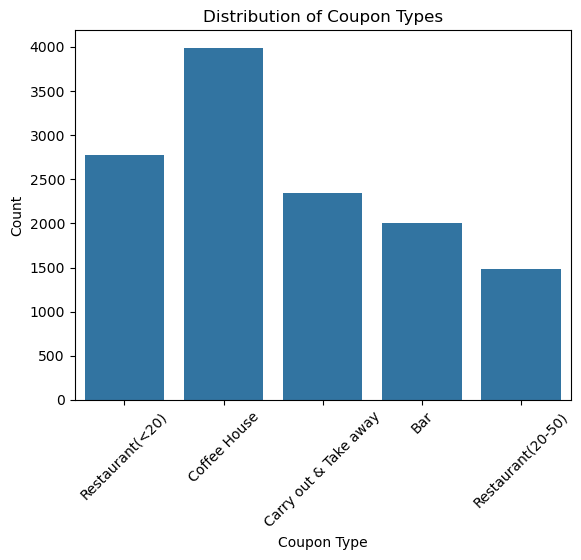

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=data_dropped, x='coupon')

plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()


Distribution of coupons isn't uniform across the dataset. Some coupon categories appear much more frequently than others. Coffee House, Restaurant (<20), and Bar coupons make up a large portion of the observations, while Carry Out & Take Away and Restaurant (20–50) coupons are less common.

6. Use a histogram to visualize the temperature column.

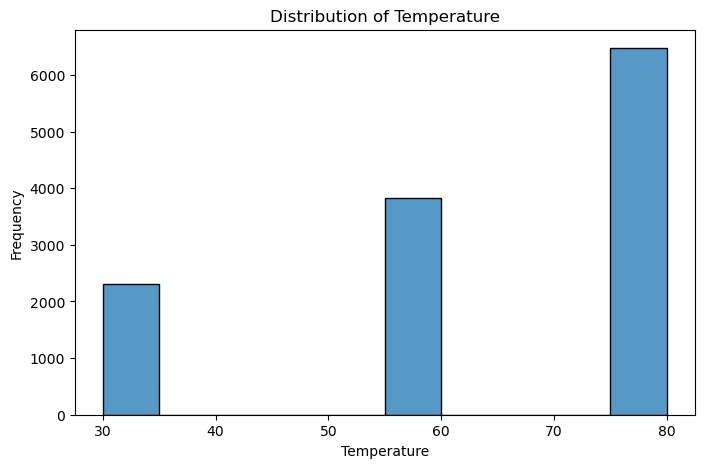

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=data_dropped, x='temperature', bins=10)

plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()


Above graph demonstrates distribution of temperature in data_dropped data set. The temperature distribution indicates that most coupon observations were collected under warm weather conditions (80°F), while fewer observations occurred during cold weather (30°F).

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [36]:
data_bar_coupons = data_dropped[data_dropped['coupon'] == 'Bar']
data_bar_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [177]:
bar_acceptance_rate = data_bar_coupons['Y'].mean()
print(f"Bar acceptance rate is: {bar_acceptance_rate:.2%}")

Bar acceptance rate is: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [178]:
print(f"Unique bar column values are: {data_bar_coupons['Bar'].unique()}")
goup_bar_less_than_three = data_bar_coupons[data_bar_coupons['Bar'].isin(['1~3', 'never', 'less1'])]
goup_bar_less_than_three['Y'].mean()
print(f"Acceptance rate of people who went to bar 3 or fewer times is: {goup_bar_less_than_three['Y'].mean():.2%}")

goup_bar_more_than_three = data_bar_coupons[data_bar_coupons['Bar'].isin(['gt8', '4~8'])]
print(f"Acceptance rate of people who went to bar more than 3 times is: {goup_bar_more_than_three['Y'].mean():.2%}")


Unique bar column values are: ['never' 'less1' '1~3' 'gt8' nan '4~8']
Acceptance rate of people who went to bar 3 or fewer times is: 37.04%
Acceptance rate of people who went to bar more than 3 times is: 76.88%


I included in my analysis the fact that customers who went to bar 3 or fewer times are the ones who went to bars never (0 times), less than 1 and between 1 to 3. According to my analysis, customers who visited bars more than three times per month accepted bar coupons at a higher rate than customers who visited bars three or fewer times per month.


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [87]:
print(f"Age of the drivers who go to bar more than once: {goup_bar_more_than_once['age'].unique()}")
#Data frame of drivers who go to a bar more than once a month and are over the age of 25 

target_group = data_bar_coupons[
    data_bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    data_bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus'])
]
#Acceptance rate of drivers who go to a bar more than once a month and are over the age of 25 

acceptance_more_than_once_age_gt_twentyfive = target_group['Y'].mean()
print(f"Acceptance rate of drivers who go to a bar more than once a month and are over the age of 25 is: {acceptance_more_than_once_age_gt_twentyfive:.2%}")


#Data frame for all other people:
all_others = data_bar_coupons.drop(target_group.index)
#Acceptance rate of all other people
acceptance_all_other_drivers = all_others['Y'].mean()
print(f"Acceptance rate of all other drivers: {acceptance_all_other_drivers: .2%}")


Age of the drivers who go to bar more than once: ['21' '26' '31' '50plus' '41' '36' '46' 'below21']
Acceptance rate of drivers who go to a bar more than once a month and are over the age of 25 is: 69.52%
Acceptance rate of all other drivers:  33.46%


Drivers who go to bars more than once per month and are older than 25 have a higher coupon acceptance rate compared to all other drivers. This suggests that frequent bar-goers older tha 25 years old are more likely to accept Bar coupons.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [108]:
target_group = data_bar_coupons[
    (data_bar_coupons['Bar'].isin(['gt8', '4~8', '1~3'])) & 
    (data_bar_coupons['passanger'].isin(['Friend(s)', 'Partner'])) & 
    (data_bar_coupons['occupation'] != 'Farming Fishing & Forestry')
    ]
acceptance_target_group = target_group['Y'].mean()
print(f"Acceptance rate of drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry is: {acceptance_target_group: .2%}")


Acceptance rate of drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry is:  71.79%


Drivers who go to bars more than once a month, travel with friends or partners, and work in occupations other than farming, fishing, or forestry had an acceptance rate of 71.79%

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [134]:
#Analyzing drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed
bar_goers_with_no_kids_not_widowed = data_bar_coupons[
    (data_bar_coupons['Bar'].isin(['gt8', '4~8', '1~3']))&
    (data_bar_coupons['passanger'].isin(['Friend(s)', 'Partner'])) & 
    (data_bar_coupons['maritalStatus'] != 'Widowed')
    ]
acceptance_bar_goers_with_no_kids_not_widowed = bar_goers_with_no_kids_not_widowed['Y'].mean()
print(f"Acceptance_rate_of_bar_goers_with_no_kids_not_widowed: {acceptance_bar_goers_with_no_kids_not_widowed:.2%}")

#Analyzing drivers who go to bars more than once a month and are under the age of 30
bar_goers_under_age_30 = data_bar_coupons[
    (data_bar_coupons['Bar'].isin(['gt8', '4~8', '1~3']))&
    (data_bar_coupons['age'].isin(['21','26','below21']))
    ]
acceptance_bar_goers_less_than_30years = bar_goers_under_age_30['Y'].mean()
print(f"Acceptance_rate_of_bar_goers_who_are_less_than_30years: {acceptance_bar_goers_less_than_30years:.2%}")

#Analyzing drivers who go to cheap restaurants more than 4 times a month and income is less than 50K
cheap_restaurant_goers_with_income_less_than_fifty_thous = data_bar_coupons[
    (data_bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (data_bar_coupons['income'].isin(['$37500 - $49999','$12500 - $24999','$25000 - $37499','Less than $12500']))
     ]
    
acceptance_rate_cheap_restaurant_goers_with_income_less_than_fifty_thous = cheap_restaurant_goers_with_income_less_than_fifty_thous['Y'].mean()
print(f"Acceptance_rate_of_cheap_restaurant_goers_with_income_less_than_fifty_thous: {acceptance_rate_cheap_restaurant_goers_with_income_less_than_fifty_thous:.2%}")
    
    


Acceptance_rate_of_bar_goers_with_no_kids_not_widowed: 71.79%
Acceptance_rate_of_bar_goers_who_are_less_than_30years: 72.17%
Acceptance_rate_of_cheap_restaurant_goers_with_income_less_than_fifty_thous: 45.35%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
41% of bar coupons were accepted. Acceptance rate of bar coupon is highest (76.8%) among the people who go to bars more than 3 times. 
    Drivers who go to bars more than once per month and are older than 25 have higher coupon acceptance rate compared to all other drivers.
    Additionally, drivers who go to bars more than once a month, travel with friends or partners, and work in occupations other than farming, fishing, or forestry has coupon acceptance rate of 71.79%
    Similarly, drivers who go to bars more than once a month, has passengers with no kid, and are not widowed also has higher coupon acceptance rate.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [171]:
#Data set of high end restaurant coupons
data_high_end_restaurant_coupons = data_dropped[data_dropped['coupon'] == 'Restaurant(20-50)']
acceptance_rate_high_end_restaurant_coupons = data_high_end_restaurant_coupons['Y'].mean()
print(f" Acceptance rate of high end restaurant coupons is: {acceptance_rate_high_end_restaurant_coupons:.2%}")

#Analyzing coupon acceptance rate of drivers that go to high end restaurants less than 3 times
drivers_dont_goto_highend_restaurants = data_high_end_restaurant_coupons[data_high_end_restaurant_coupons['Restaurant20To50'].isin(['never', 'less1', '1~3'])]
acceptance_drivers_dont_goto_highend_restaurants = drivers_dont_goto_highend_restaurants['Y'].mean()
print(f"Coupon acceptance rate of drivers who go to high end restaurants less than 3 times: {acceptance_drivers_dont_goto_highend_restaurants:.2%}")

#Analyzing coupon acceptance rate of drivers that go to high end restaurants more than 3 times
drivers_that_goto_highend_restaurants = data_high_end_restaurant_coupons[data_high_end_restaurant_coupons['Restaurant20To50'].isin(['gt8', '4~8'])]

acceptance_drivers_goto_highend_restaurants = drivers_that_goto_highend_restaurants['Y'].mean()
print(f"Coupon acceptance rate of drivers who go to high end restaurants more than 3 times: {acceptance_drivers_goto_highend_restaurants:.2%}")

#Analyzing drivers who doesn't drive alone and who go to high end restaurants more than 3 times
drivers_dont_drive_alone_frequent_highend_restgoers = data_high_end_restaurant_coupons[
    (data_high_end_restaurant_coupons['passanger'].isin(['Partner', 'Friend(s)', 'Kid(s)'])) &
    (data_high_end_restaurant_coupons['Restaurant20To50'].isin(['4~8', 'gt8']))
]
acceptance_drivers_dont_drive_alone_frequent_highend_restgoers = drivers_dont_drive_alone_frequent_highend_restgoers['Y'].mean()
print(f"Coupon acceptance rate of drivers that dont drive alone and frequent highend restgoers: {acceptance_drivers_dont_drive_alone_frequent_highend_restgoers:.2%}")
    
#Analyzing drivers who drive with friends an partner only and who go to high end restaurants more than 3 times
drivers_with_partner_and_friend_and_frequent_highend_restgoers = data_high_end_restaurant_coupons[
    (data_high_end_restaurant_coupons['passanger'].isin(['Partner', 'Friend(s)'])) &
    (data_high_end_restaurant_coupons['Restaurant20To50'].isin(['4~8', 'gt8']))
]
acceptance_drivers_with_partner_and_friend_and_frequent_highend_restgoers = drivers_with_partner_and_friend_and_frequent_highend_restgoers['Y'].mean()
print(f"Coupon acceptance rate of drivers with partner and friend and frequent highend restgoers: {acceptance_drivers_with_partner_and_friend_and_frequent_highend_restgoers:.2%}")


 Acceptance rate of high end restaurant coupons is: 44.15%
Coupon acceptance rate of drivers who go to high end restaurants less than 3 times: 42.52%
Coupon acceptance rate of drivers who go to high end restaurants more than 3 times: 64.23%
Coupon acceptance rate of drivers that dont drive alone and frequent highend restgoers: 58.97%
Coupon acceptance rate of drivers with partner and friend and frequent highend restgoers: 65.22%


In [ ]:
High-end restaurant coupons have a lower acceptance rate (44.15%) than the overall coupon acceptance rate (found above 56.76%), suggesting customers may be more selective when deciding whether to visit higher-priced restaurants.
Additionally, Frequent diners accepted coupons at 64.23%, which is approximately 51% higher than the acceptance rate among infrequent diners (42.52%).

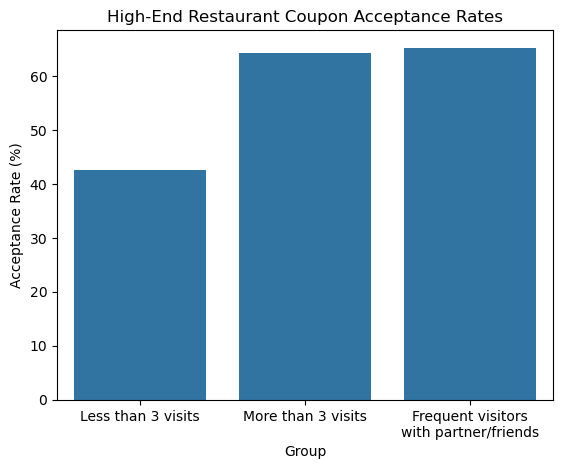

In [176]:
comparison = pd.DataFrame({
    'Group': [
        'Less than 3 visits',
        'More than 3 visits',
        'Frequent visitors\nwith partner/friends'
    ],
    'Acceptance Rate': [
        42.52,
        64.23,
        65.22
    ]
})

sns.barplot(data=comparison, x='Group', y='Acceptance Rate')
plt.title('High-End Restaurant Coupon Acceptance Rates')
plt.ylabel('Acceptance Rate (%)')
plt.show()

Above graph visually demonstrates that frequent restaurant-goers are more likely to accept coupons.
The results suggest that prior dining behavior is a strong predictor of coupon acceptance. Drivers who frequently dine at high-end restaurants are about 22 percentage points more likely to accept a high-end restaurant coupon than those who rarely visit such establishments (64.23% vs. 42.52%).

Additionally, social context appears to influence acceptance rates. Frequent high-end restaurant visitors traveling with partners or friends represent the most receptive customer segment, with a 65.22% acceptance rate. Therefore, marketing efforts for high-end restaurant coupons may be most effective when targeted toward customers who regularly dine at similar restaurants and are traveling with companions.